# Twitter Sentiment Analysis Project

This project demonstrates how to perform sentiment analysis on tweet data using machine learning techniques.

---

### 🔹 What This Notebook Does:
- Preprocesses tweet text using one-hot-like encoding (binary Bag-of-Words)
- Trains a Logistic Regression model to classify tweet sentiment (positive, negative, neutral)
- Validates the model using 3-fold cross-validation
- Analyzes sentiment trends over time using timestamp data

---

### 📂 Dataset Source:

**Note:** This notebook currently uses a **simulated (manually created)** dataset of 10 example tweets for demonstration.  
For your actual Final Year Project (FYP), replace this with a real dataset from:

- [✅ Kaggle: Sentiment140](https://www.kaggle.com/datasets/kazanova/sentiment140)
- [✅ Kaggle: Twitter US Airline Sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment)

You may also optionally collect tweets in real time using the Twitter API via [Tweepy](https://www.tweepy.org/).

---


Importing Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


loading data

In [2]:
# Load the uploaded CSV file
df = pd.read_csv("/content/twitter airline training data.csv")

# Preview
df.head()


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,5.703060e+17,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,24/02/2015 11:35,NaN,Eastern Time (US & Canada)
1,5.703010e+17,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,24/02/2015 11:15,NaN,Pacific Time (US & Canada)
2,5.703010e+17,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,24/02/2015 11:15,Lets Play,Central Time (US & Canada)
3,5.703010e+17,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,24/02/2015 11:15,NaN,Pacific Time (US & Canada)
4,5.703010e+17,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,24/02/2015 11:14,NaN,Pacific Time (US & Canada)


rename columns

In [3]:
train_df = pd.read_csv("/content/twitter airline training data.csv")
train_df = train_df[["text", "airline_sentiment"]]
train_df.columns = ["tweet", "sentiment"]



In [4]:
df = pd.read_csv("/content/twitter airline training data.csv")
df = df[["text", "airline_sentiment", "tweet_created"]]  # Keep timestamp!
df.columns = ["tweet", "sentiment", "timestamp"]         # Rename all three
df["timestamp"] = pd.to_datetime(df["timestamp"])



<ipython-input-4-cc543525d36c>:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["timestamp"] = pd.to_datetime(df["timestamp"])


Creating and Training the Pipeline

In [5]:
X = df['tweet']
y = df['sentiment']

pipeline = Pipeline([
    ('vectorizer', CountVectorizer(binary=True)),  # Binary bag-of-words (similar to one-hot)
    ('classifier', LogisticRegression(max_iter=200))
])


pipeline.fit(X, y)
print("Model trained using airline sentiment data!")


Model trained using airline sentiment data!


one hot encoding testing

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('vectorizer', CountVectorizer(binary=True)),  # One-Hot Encoding
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    negative       0.87      0.89      0.88      1889
     neutral       0.62      0.60      0.61       580
    positive       0.74      0.71      0.73       459

    accuracy                           0.80      2928
   macro avg       0.74      0.73      0.74      2928
weighted avg       0.80      0.80      0.80      2928



In [20]:
pipeline.predict(["I am so disappointed by the airline service"])


array(['negative'], dtype=object)

Cross-Validation and Final Model Evaluation:

In [6]:
# Cross-validation
cv_scores = cross_val_score(pipeline, X, y, cv=3, scoring='accuracy')
print("Cross-validation scores:", cv_scores)

# Train and predict
pipeline.fit(X, y)
df['predicted_sentiment'] = pipeline.predict(X)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y, df['predicted_sentiment']))

Cross-validation scores: [0.76864754 0.71659836 0.74098361]

Classification Report:

              precision    recall  f1-score   support

    negative       0.96      0.98      0.97      9178
     neutral       0.92      0.87      0.89      3099
    positive       0.94      0.92      0.93      2363

    accuracy                           0.95     14640
   macro avg       0.94      0.92      0.93     14640
weighted avg       0.95      0.95      0.95     14640



In [7]:
print(df.columns)


Index(['tweet', 'sentiment', 'timestamp', 'predicted_sentiment'], dtype='object')


Plotting Sentiment Trends Over Time:

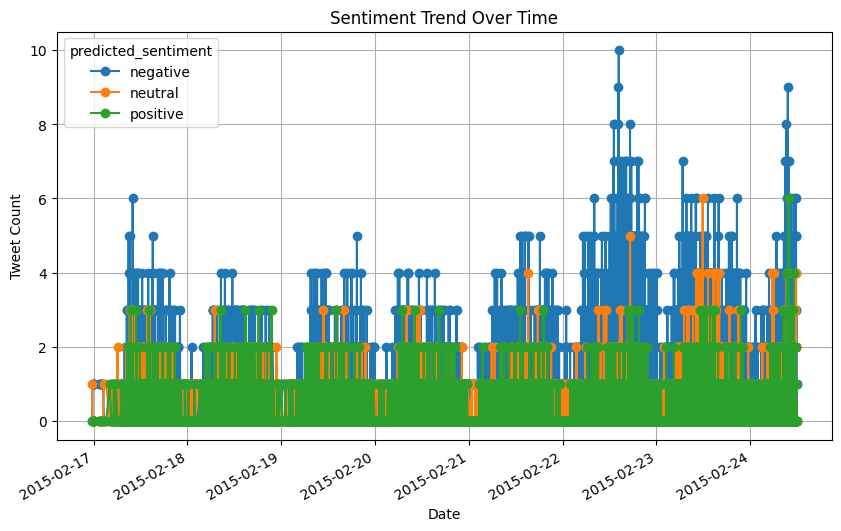

In [8]:
# Trend analysis: sentiment over time
sentiment_trend = df.groupby(['timestamp', 'predicted_sentiment']).size().unstack().fillna(0)

# Plot sentiment trends
sentiment_trend.plot(figsize=(10, 6), marker='o')
plt.title("Sentiment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Tweet Count")
plt.grid(True)
plt.show()


## 🗄️ Storing Tweets in SQLite Database

This section demonstrates how to save tweets and their predicted sentiments into an SQLite database and query sentiment-based results.


In [9]:
import sqlite3

# Connect to SQLite database (or create it if it doesn't exist)
conn = sqlite3.connect('sentiment_analysis.db')

# Store dataframe in a table named 'tweets'
df.to_sql('tweets', conn, if_exists='replace', index=False)
print("Data stored in SQLite database.")

# Query: Show all negative tweets
negative_tweets = pd.read_sql_query("SELECT * FROM tweets WHERE predicted_sentiment = 'negative'", conn)
negative_tweets.head()


Data stored in SQLite database.


,tweet,sentiment,timestamp,predicted_sentiment
0,@VirginAmerica it's really aggressive to blast...,negative,2015-02-24 11:15:00,negative
1,@VirginAmerica and it's a really big bad thing...,negative,2015-02-24 11:14:00,negative
2,@VirginAmerica seriously would pay $30 a fligh...,negative,2015-02-24 11:14:00,negative
3,"@virginamerica Well, I didn't…but NOW I DO! :-D",positive,2015-02-24 11:11:00,negative
4,@VirginAmerica SFO-PDX schedule is still MIA.,negative,2015-02-24 10:01:00,negative


In [10]:
print(train_df.columns)


Index(['tweet', 'sentiment'], dtype='object')


Training the Model with Airline Sentiment Data:

In [11]:
# Load training data from Sentiment140 sample
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

train_df = pd.read_csv("/content/twitter airline training data.csv")

X_train = train_df['text']                    # Use the actual tweet content
y_train = train_df['airline_sentiment']      # Use the sentiment label


# Build the sentiment analysis pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer(binary=True)),
    ('classifier', LogisticRegression(max_iter=200))
])

# Train the model
pipeline.fit(X_train, y_train)
print("Model trained on airline data.")


Model trained on airline data.


Live Tweet Analysis and Storage Pipeline

In [12]:
# STEP 1: Install Tweepy if needed
!pip install tweepy

# STEP 2: Import and setup Tweepy
import tweepy
import sqlite3

# Twitter API Bearer Token (replace this with your actual token)
bearer_token = "AAAAAAAAAAAAAAAAAAAAALbG1AEAAAAAPJhS4F8jrfE%2Fmf1rngQIFisxrG8%3DRD8KqUjrWAw3k0jVcPG9ZDgqEnxG3ahJOq7IlKFfgTdMzCjrIQ"
client = tweepy.Client(bearer_token=bearer_token)

# STEP 3: Fetch tweets by keyword or hashtag
query = "Pakistan India -is:retweet -is:reply lang:en"
response = client.search_recent_tweets(query=query, max_results=10, tweet_fields=["created_at", "text"])

# STEP 4: Convert tweets to DataFrame
tweets_data = [{"tweet": tweet.text, "timestamp": tweet.created_at} for tweet in response.data]
live_df = pd.DataFrame(tweets_data)

# STEP 5: Predict sentiment using existing model pipeline
live_df["predicted_sentiment"] = pipeline.predict(live_df["tweet"])

# STEP 6: Store in SQLite database
conn = sqlite3.connect("sentiment_analysis.db")
live_df.to_sql("live_tweets", conn, if_exists="replace", index=False)

# STEP 7: Display the result
print("✅ Live tweets fetched, analyzed, and stored!")
live_df


✅ Live tweets fetched, analyzed, and stored!


,tweet,timestamp,predicted_sentiment
0,#Putin meets #Zelensky this week for the first...,2025-05-12 11:43:03+00:00,negative
1,#WATCH | Indian military shows the debris of a...,2025-05-12 11:43:01+00:00,negative
2,India's firm response through Op Sindoor again...,2025-05-12 11:43:00+00:00,neutral
3,Pakistan India war ended.\nThe sound of explos...,2025-05-12 11:42:59+00:00,negative
4,"Decided to Fact Check @ndtv headline ""The Paki...",2025-05-12 11:42:54+00:00,negative
5,Nirmala tai should add 10% more tax on all tho...,2025-05-12 11:42:42+00:00,negative
6,What offended Delhi was not simply the US effo...,2025-05-12 11:42:42+00:00,neutral
7,Things I realised from Indian Pakistan War:-\n...,2025-05-12 11:42:42+00:00,negative
8,Today a corrupt Indian Prime Minister @narendr...,2025-05-12 11:42:42+00:00,negative
9,When India fought with Pakistan no one cricket...,2025-05-12 11:42:39+00:00,negative


# **⚠️ Detect Hate or Negative Sentiment Toward Pakistan**

real-time sentiment analysis on the Pakistan–India conflict to detect negativity or hate toward Pakistan

In [13]:
# STEP 1: Install Tweepy if needed
!pip install tweepy

# STEP 2: Import and setup Tweepy
import tweepy
import sqlite3

# Twitter API Bearer Token (replace this with your actual token)
bearer_token = "AAAAAAAAAAAAAAAAAAAAALbG1AEAAAAAPJhS4F8jrfE%2Fmf1rngQIFisxrG8%3DRD8KqUjrWAw3k0jVcPG9ZDgqEnxG3ahJOq7IlKFfgTdMzCjrIQ"
client = tweepy.Client(bearer_token=bearer_token)

# STEP 3: Fetch tweets by keyword or hashtag
query = 'pakistan (terrorist OR attack OR threat OR war OR hate) -is:retweet -is:reply lang:en'
response = client.search_recent_tweets(query=query, max_results=10, tweet_fields=["created_at", "text"])

# STEP 4: Convert tweets to DataFrame
tweets_data = [{"tweet": tweet.text, "timestamp": tweet.created_at} for tweet in response.data]
live_df = pd.DataFrame(tweets_data)

# STEP 5: Predict sentiment using existing model pipeline
live_df["predicted_sentiment"] = pipeline.predict(live_df["tweet"])

# Filter only tweets that are negative AND mention Pakistan
anti_pak = live_df[
    (live_df["predicted_sentiment"] == "negative") &
    (live_df["tweet"].str.contains("pakistan", case=False))
]
anti_pak = anti_pak.reset_index(drop=True)

# STEP 6: Store in SQLite database
conn = sqlite3.connect("anti_pakistan_sentiment.db")
anti_pak.to_sql("anti_pak_tweets", conn, if_exists="replace", index=False)
anti_pak = anti_pak.sort_values("timestamp", ascending=False)

# STEP 7: Display the result
print("✅ Live tweets fetched, analyzed, and stored!")
anti_pak


TooManyRequests: 429 Too Many Requests
Too Many Requests

Visualizing Sentiment Trends with Graphs

<ipython-input-14-5e64bf339eeb>:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  trend = live_df.groupby([live_df['timestamp'].dt.floor('H'), 'predicted_sentiment']).size().unstack().fillna(0)


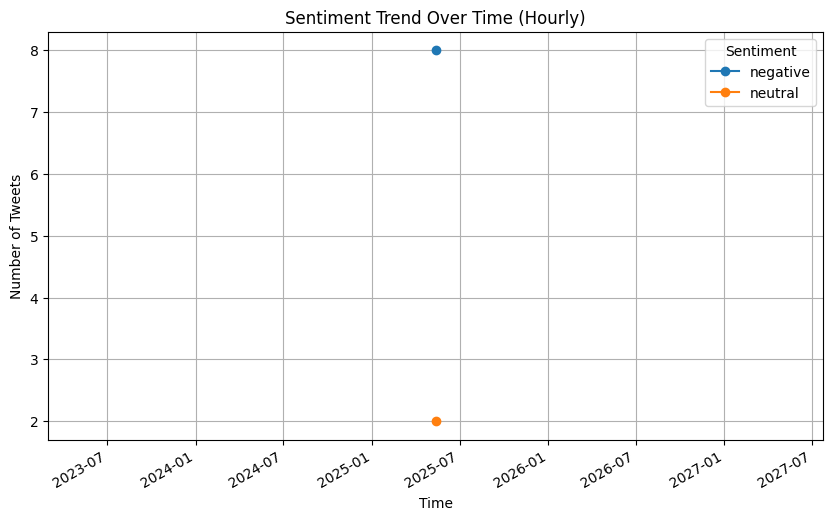

In [14]:
import matplotlib.pyplot as plt

# Make sure timestamp is in datetime format
live_df['timestamp'] = pd.to_datetime(live_df['timestamp'])

# Group tweets by HOUR and sentiment
trend = live_df.groupby([live_df['timestamp'].dt.floor('H'), 'predicted_sentiment']).size().unstack().fillna(0)

# Plot the trend
trend.plot(kind='line', marker='o', figsize=(10, 6))
plt.title("Sentiment Trend Over Time (Hourly)")
plt.xlabel("Time")
plt.ylabel("Number of Tweets")
plt.grid(True)
plt.legend(title="Sentiment")
plt.show()


<ipython-input-16-cdec5d109e43>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=live_df, x='predicted_sentiment', palette='Set2')


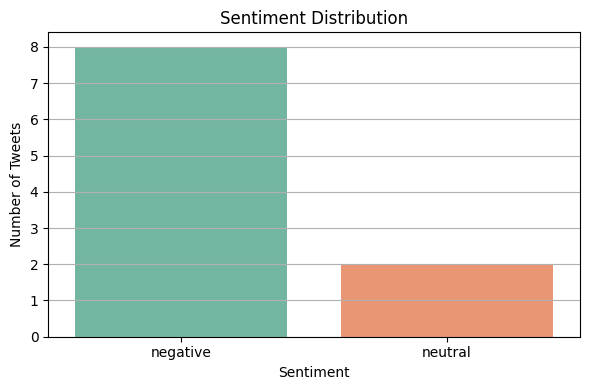

In [16]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=live_df, x='predicted_sentiment', palette='Set2')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


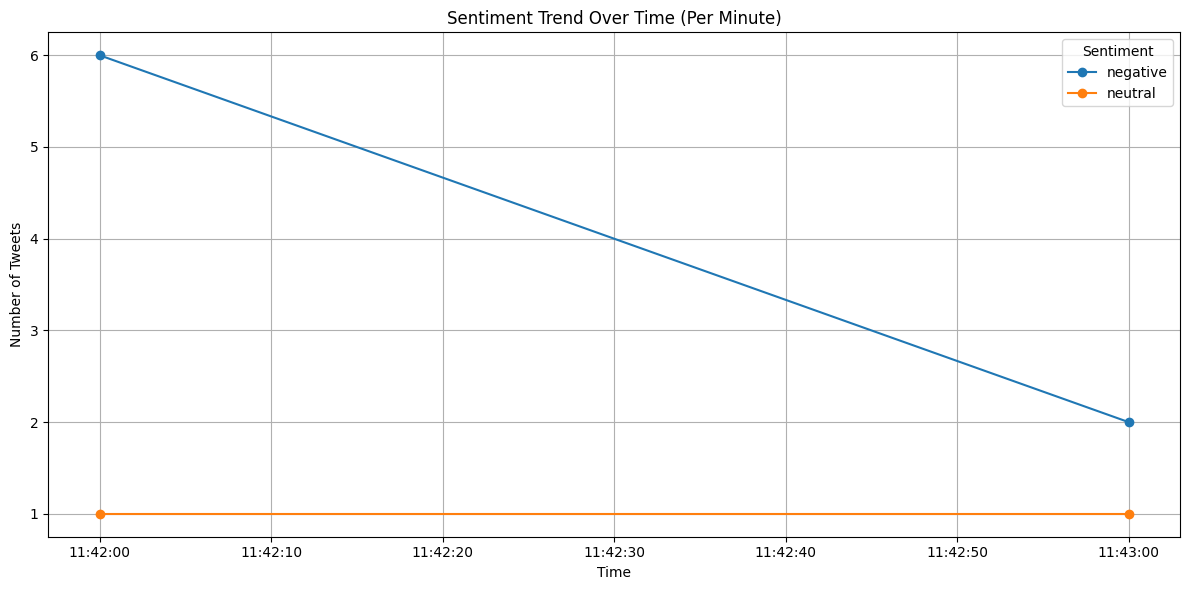

In [17]:
trend = live_df.groupby([
    live_df['timestamp'].dt.floor('min'),
    'predicted_sentiment'
]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
for sentiment in trend.columns:
    plt.plot(trend.index, trend[sentiment], label=sentiment, marker='o')

plt.title("Sentiment Trend Over Time (Per Minute)")
plt.xlabel("Time")
plt.ylabel("Number of Tweets")
plt.legend(title="Sentiment")
plt.grid(True)
plt.tight_layout()
plt.show()


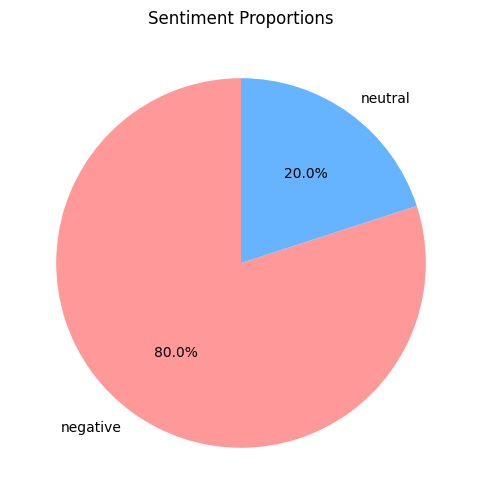

In [18]:
live_df['predicted_sentiment'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    figsize=(6, 6),
    colors=['#ff9999','#66b3ff','#99ff99']
)
plt.title("Sentiment Proportions")
plt.ylabel("")
plt.show()
